# Multimodal Cardiac Fusion Model V6 — Pretrained Encoders, Binary Classification
**Task:** Normal vs Abnormal screening for structural disease AND arrhythmia (multi-task)
**Architecture:** Pretrained 1D-ResNet+Transformer (ECG) + Pretrained ResNet50 (Echo) → Cross-Attention Fusion → 2× binary heads

**Key changes from V5:**
- ECG encoder config updated to match PTB-XL pretrained weights (`seq_len=128`, `trans_layers=2`)
- Both encoders are **permanently frozen** — only fusion layers and classifier heads train
- 3-stage curriculum removed — single training phase with pretrained frozen features
- Pretrained ECG encoder weights loaded from `ecg_encoder_pretrained.pt`
- Echo backbone uses ImageNet-pretrained ResNet50 (frozen)

**Data:** V3 preprocessed `.npz` files with 5 structural classes and 5 arrhythmia classes,
mapped to binary (normal vs abnormal) on the fly.

## 0 · Environment Check

In [1]:
import torch

print(f"PyTorch   : {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {props.total_memory / 1e9:.1f} GB")
    print(f"VRAM free : {(props.total_memory - torch.cuda.memory_reserved(0)) / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")

PyTorch   : 2.11.0+cu128
CUDA avail: True
GPU       : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM      : 8.6 GB
VRAM free : 8.6 GB

Using device: cuda


## 1 · Configuration

**Binary setup:**
- Structural: class 2 (normal) → label 0, everything else → label 1 (abnormal)
- Arrhythmia: class 1 (normal) → label 0, everything else → label 1 (abnormal)

**5-class label indices in the .npz files:**
- Structural (5 classes): 0=ASD/VSD, 1=Cardiomyopathy, **2=Normal**, 3=Pericardial, 4=Valvular
- Arrhythmia (5 classes): 0=AV Block, **1=Normal Sinus**, 2=Afib/Flutter, 3=SVT, 4=VT/Vfib

**ECG encoder config MUST match pretrained checkpoint:**
- `ECG_SEQ_LEN = 128`  (was 32 in V5 — updated to match PTB-XL pretrained encoder)
- `ECG_TRANS_LAYERS = 2` (was 1 in V5 — updated to match PTB-XL pretrained encoder)

In [2]:
import os, random
import numpy as np
import torch

# ── Paths ─────────────────────────────────────────────────────────────────────
CACHE_DIR  = r"C:\Users\anwme\Desktop\Datasets\cache_v3"
OUTPUT_DIR = r"C:\Users\anwme\Desktop\Datasets\model_output_binary_v6"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Pretrained ECG encoder weights ────────────────────────────────────────────
# This file contains ONLY the ECGEncoder state_dict (no classification head).
# Saved by ecg_encoder_pretrain_ptbxl notebook: model.encoder.state_dict()
PRETRAINED_ECG_CKPT = r"C:\Users\anwme\Desktop\Datasets\ecg_encoder_pretrained.pt"

# ── Data ──────────────────────────────────────────────────────────────────────
ECG_LEADS   = 12
ECG_LEN     = 5000
ECHO_SIZE   = 224
ECHO_FRAMES = 3

# ── Task (binary) ─────────────────────────────────────────────────────────────
NUM_CLASSES_STRUCT = 2
NUM_CLASSES_ARR    = 2
STRUCT_CLASSES = ['normal', 'abnormal']
ARR_CLASSES    = ['normal', 'abnormal']

# In the 5-class labels stored in the .npz files:
#   Structural (5 classes): 0=ASD/VSD, 1=Cardiomyopathy, 2=Normal, 3=Pericardial, 4=Valvular
#   Arrhythmia (5 classes): 0=AV Block, 1=Normal Sinus, 2=Afib/Flutter, 3=SVT, 4=VT/Vfib
STRUCT_NORMAL_IDX = 2   # class index 2 = Normal in structural labels
ARR_NORMAL_IDX    = 1   # class index 1 = Normal Sinus in arrhythmia labels

LAMBDA_STRUCT = 1.0
LAMBDA_ARR    = 1.0

# ── Model ─────────────────────────────────────────────────────────────────────
ECG_BASE_DIM  = 256
ECHO_BASE_DIM = 2048
PROJ_DIM      = 256
ATTN_HEADS    = 4
ATTN_LAYERS   = 2
ATTN_DROPOUT  = 0.1
MLP_DROPOUT   = 0.4

# ── ECG encoder config — MUST match pretrained checkpoint exactly ─────────────
ECG_SEQ_LEN      = 128   # was 32 in V5 — matches PTB-XL pretrained encoder
ECG_TRANS_LAYERS = 2     # was 1 in V5 — matches PTB-XL pretrained encoder

# ── Training (single stage — encoders frozen) ────────────────────────────────
BATCH_SIZE = 16
EPOCHS     = 50
LR         = 8e-5
PATIENCE   = 15
SEED       = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Config OK — binary screening (normal vs abnormal)")
print(f"  ECG_SEQ_LEN      = {ECG_SEQ_LEN}  (matches pretrained encoder)")
print(f"  ECG_TRANS_LAYERS = {ECG_TRANS_LAYERS}  (matches pretrained encoder)")

Device: cuda
Config OK — binary screening (normal vs abnormal)
  ECG_SEQ_LEN      = 128  (matches pretrained encoder)
  ECG_TRANS_LAYERS = 2  (matches pretrained encoder)


## 2 · Dataset & DataLoaders

Loads the 5-class `.npz` files and maps labels to binary (0=normal, 1=abnormal) on the fly.

**Label mapping verification:**
- `label_struct_coarse`: 5 structural classes → binary via `!= 2` (class 2 = Normal)
- `label_arr_coarse`: 5 arrhythmia classes → binary via `!= 1` (class 1 = Normal Sinus)

In [3]:
import json
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy.ndimage import rotate as ndimage_rotate, gaussian_filter


class CardiacDatasetBinary(Dataset):
    def __init__(self, npz_path, augment=False):
        data         = np.load(npz_path, mmap_mode='r')
        self.ecg     = data['ecg']
        self.echo    = data['echo']
        self.augment = augment
        self.echo_mean = torch.tensor([0.449], dtype=torch.float32)
        self.echo_std  = torch.tensor([0.226], dtype=torch.float32)

        # ── Verify .npz contains expected arrays ─────────────────────────
        print(f"  Loading: {npz_path}")
        print(f"    ECG shape : {self.ecg.shape}")
        print(f"    Echo shape: {self.echo.shape}")

        # Map 5-class → binary: normal=0, abnormal=1
        raw_struct = data['label_struct_coarse'].copy()
        raw_arr    = data['label_arr_coarse'].copy()

        # Verify we have 5 classes in each
        n_struct_classes = len(np.unique(raw_struct))
        n_arr_classes    = len(np.unique(raw_arr))
        print(f"    Structural classes found: {np.unique(raw_struct)} ({n_struct_classes} unique)")
        print(f"    Arrhythmia classes found: {np.unique(raw_arr)} ({n_arr_classes} unique)")

        self.labels_struct = (raw_struct != STRUCT_NORMAL_IDX).astype(np.int64)
        self.labels_arr    = (raw_arr    != ARR_NORMAL_IDX).astype(np.int64)

        ns = np.bincount(self.labels_struct, minlength=2)
        na = np.bincount(self.labels_arr,    minlength=2)
        print(f'  Structural: normal={ns[0]}  abnormal={ns[1]}')
        print(f'  Arrhythmia: normal={na[0]}  abnormal={na[1]}')

    def __len__(self):
        return len(self.labels_struct)

    def _augment_ecg(self, ecg):
        ecg = ecg * np.random.uniform(0.8, 1.2)
        ecg = ecg + np.random.randn(*ecg.shape).astype(np.float32) * 0.05
        shift = np.random.randint(0, 500)
        ecg = np.concatenate([ecg[:, shift:],
                               np.zeros((ecg.shape[0], shift), dtype=np.float32)], axis=1)
        if np.random.rand() > 0.5:
            n_drop = np.random.randint(1, 3)
            drop_idx = np.random.choice(12, n_drop, replace=False)
            ecg[drop_idx] = 0
        if np.random.rand() > 0.5:
            ecg = -ecg
        return ecg

    def _augment_echo(self, echo):
        if np.random.rand() > 0.5:
            echo = echo[:, :, ::-1].copy()
        if np.random.rand() > 0.5:
            gain = np.random.uniform(0.8, 1.2)
            bias = np.random.uniform(-15, 15)
            echo = np.clip(echo.astype(np.float32) * gain + bias, 0, 255).astype(np.uint8)
        if np.random.rand() > 0.3:
            sigma = np.random.uniform(0.5, 1.5)
            for f in range(echo.shape[0]):
                echo[f] = gaussian_filter(echo[f].astype(np.float32), sigma=sigma).astype(np.uint8)
        if np.random.rand() > 0.5:
            angle = np.random.uniform(-10, 10)
            for f in range(echo.shape[0]):
                echo[f] = ndimage_rotate(echo[f], angle, reshape=False, order=1, mode='nearest')
        return echo

    def __getitem__(self, idx):
        ecg  = self.ecg[idx].copy().astype(np.float32)
        echo = self.echo[idx].copy()
        lbl_s = int(self.labels_struct[idx])
        lbl_a = int(self.labels_arr[idx])

        ecg = np.nan_to_num(ecg, nan=0.0, posinf=8.0, neginf=-8.0)
        ecg = np.clip(ecg, -8.0, 8.0)

        if self.augment:
            ecg  = self._augment_ecg(ecg)
            echo = self._augment_echo(echo)

        ecg_t  = torch.from_numpy(ecg)
        echo_t = torch.from_numpy(echo.astype(np.float32) / 255.0)
        echo_t = (echo_t - self.echo_mean.view(1, 1, 1)) / self.echo_std.view(1, 1, 1)

        return (ecg_t, echo_t,
                torch.tensor(lbl_s, dtype=torch.long),
                torch.tensor(lbl_a, dtype=torch.long))


train_ds = CardiacDatasetBinary(os.path.join(CACHE_DIR, 'train.npz'), augment=True)
val_ds   = CardiacDatasetBinary(os.path.join(CACHE_DIR, 'val.npz'),   augment=False)
test_ds  = CardiacDatasetBinary(os.path.join(CACHE_DIR, 'test.npz'),  augment=False)

# Combined sampler across both binary tasks (4 combos)
combined_labels = train_ds.labels_struct * 2 + train_ds.labels_arr
counts_c = np.bincount(combined_labels).astype(float)
counts_c = np.where(counts_c == 0, 1.0, counts_c)
sample_weights = (1.0 / counts_c)[combined_labels]
sampler = WeightedRandomSampler(sample_weights, len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"\nTrain : {len(train_ds):>5d}")
print(f"Val   : {len(val_ds):>5d}")
print(f"Test  : {len(test_ds):>5d}")

  Loading: C:\Users\anwme\Desktop\Datasets\cache_v3\train.npz
    ECG shape : (3205, 12, 5000)
    Echo shape: (3205, 3, 224, 224)
    Structural classes found: [0 1 2 3 4] (5 unique)
    Arrhythmia classes found: [0 1 2 3 4] (5 unique)
  Structural: normal=595  abnormal=2610
  Arrhythmia: normal=932  abnormal=2273
  Loading: C:\Users\anwme\Desktop\Datasets\cache_v3\val.npz
    ECG shape : (468, 12, 5000)
    Echo shape: (468, 3, 224, 224)
    Structural classes found: [0 1 2 3 4] (5 unique)
    Arrhythmia classes found: [0 1 2 3 4] (5 unique)
  Structural: normal=59  abnormal=409
  Arrhythmia: normal=110  abnormal=358
  Loading: C:\Users\anwme\Desktop\Datasets\cache_v3\test.npz
    ECG shape : (958, 12, 5000)
    Echo shape: (958, 3, 224, 224)
    Structural classes found: [0 1 2 3 4] (5 unique)
    Arrhythmia classes found: [0 1 2 3 4] (5 unique)
  Structural: normal=108  abnormal=850
  Arrhythmia: normal=248  abnormal=710

Train :  3205
Val   :   468
Test  :   958


## 3 · Model Architecture

Same fusion architecture as V5, with two critical config changes to match the pretrained ECG encoder:
- `ECG_SEQ_LEN = 128` (was 32)
- `ECG_TRANS_LAYERS = 2` (was 1)

After instantiation, the pretrained ECG encoder weights are loaded and **both encoders are frozen permanently**.

In [4]:
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch import Tensor
from typing import List, Dict, Union, Tuple


# ── A. ECG ENCODER — 1D ResNet ───────────────────────────────────────────────
# IDENTICAL architecture to ecg_encoder_pretrain_ptbxl notebook.
# Config params (ECG_SEQ_LEN=128, ECG_TRANS_LAYERS=2) ensure weight compatibility.

class Conv1dBnRelu(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size,
                      stride=stride, padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))


class ResNet1D(nn.Module):
    def __init__(self, in_channels, base_filters, block_counts, out_dim):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_filters, kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )
        stages, ch_in, ch_out = [], base_filters, base_filters
        for stage_idx, n_blocks in enumerate(block_counts):
            stride = 2 if stage_idx > 0 else 1
            stages.append(self._make_stage(ch_in, ch_out, n_blocks, stride))
            ch_in  = ch_out
            ch_out = ch_out * 2
        self.stages = nn.Sequential(*stages)
        final_ch = base_filters * (2 ** (len(block_counts) - 1))
        self.channel_adapter = nn.Sequential(
            nn.Conv1d(final_ch, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(inplace=True),
        )

    @staticmethod
    def _make_stage(in_channels, out_channels, n_blocks, stride):
        blocks = [ResidualBlock1D(in_channels, out_channels, stride=stride)]
        for _ in range(1, n_blocks):
            blocks.append(ResidualBlock1D(out_channels, out_channels))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        return self.channel_adapter(x)


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class ECGEncoder(nn.Module):
    """
    Exact architecture from ecg_encoder_pretrain_ptbxl notebook.
    (B, 12, T) -> ResNet1D -> AdaptivePool -> SinPE -> Transformer -> (B, seq_len, d_model)
    """
    def __init__(self, cfg: dict):
        super().__init__()
        d_model  = cfg['transformer_d_model']
        seq_len  = cfg['transformer_seq_len']
        n_head   = cfg['transformer_nhead']
        n_layers = cfg['transformer_num_layers']
        dim_ff   = cfg['transformer_dim_ff']
        dropout  = cfg['transformer_dropout']

        self.backbone = ResNet1D(
            in_channels  = cfg['resnet_in_channels'],
            base_filters = cfg['resnet_base_filters'],
            block_counts = cfg['resnet_blocks'],
            out_dim      = cfg['resnet_out_dim'],
        )
        self.adaptive_pool = nn.AdaptiveAvgPool1d(seq_len)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=seq_len, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_head, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, norm=nn.LayerNorm(d_model)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = self.adaptive_pool(features)
        tokens   = features.permute(0, 2, 1).contiguous()
        tokens   = self.pos_enc(tokens)
        tokens   = self.transformer(tokens)
        return tokens


print('ECG encoder blocks defined (matching pretrained architecture).')


# ── B. Phase Tokenizer ───────────────────────────────────────────────────────

class AttentionPooling(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.score = nn.Linear(d_in, 1)
        self.proj  = nn.Linear(d_in, d_out)

    def forward(self, x):
        weights = F.softmax(self.score(x), dim=1)
        pooled  = (weights * x).sum(dim=1)
        return self.proj(pooled)


class PhaseTokenizer(nn.Module):
    PHASE_NAMES = ['P', 'QRS', 'T']

    def __init__(self, token_dim, phase_dim, n_phases=3):
        super().__init__()
        assert n_phases == 3
        self.n_phases  = n_phases
        self.phase_dim = phase_dim
        self.heads = nn.ModuleList([
            AttentionPooling(token_dim, phase_dim)
            for _ in range(n_phases)
        ])
        self.phase_type_emb = nn.Embedding(n_phases, phase_dim)
        self.ln = nn.ModuleList([nn.LayerNorm(phase_dim) for _ in range(n_phases)])

    def forward(self, tokens):
        out = {}
        stacked = []
        for i, (name, head, ln) in enumerate(
            zip(self.PHASE_NAMES, self.heads, self.ln)
        ):
            phase_idx = torch.tensor(i, device=tokens.device)
            pooled    = head(tokens)
            type_emb  = self.phase_type_emb(phase_idx)
            pooled    = ln(pooled + type_emb.unsqueeze(0))
            out[name] = pooled
            stacked.append(pooled)
        out['stacked'] = torch.stack(stacked, dim=1)
        return out


print('PhaseTokenizer defined.')


# ── C. ECHO ENCODER — ResNet50 shared across frames ──────────────────────────

class EchoBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        old = bb.conv1
        new = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        new.weight.data = old.weight.data.mean(dim=1, keepdim=True)
        bb.conv1 = new
        self.backbone = nn.Sequential(*list(bb.children())[:-1])

    def forward(self, x):
        x = self.backbone(x)
        return x.flatten(1)


class CycleAwareEchoEncoder(nn.Module):
    def __init__(self, in_dim=2048, d_model=256, n_heads=4, n_layers=2,
                 dropout=0.1, use_cls_token=True):
        super().__init__()
        self.backbone = EchoBackbone()
        self.use_cls_token = use_cls_token
        self.proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )
        self.phase_emb = nn.Embedding(3, d_model)
        if use_cls_token:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, norm=nn.LayerNorm(d_model),
        )

    def forward(self, echo):
        B, F, H, W = echo.shape
        assert F == 3, "Expected 3 frames: ED, Mid, ES"
        x = echo.view(B * F, 1, H, W)
        feats = self.backbone(x)
        feats = self.proj(feats)
        tokens = feats.view(B, F, -1)
        phase_ids = torch.arange(3, device=echo.device)
        phase_emb = self.phase_emb(phase_ids)
        tokens = tokens + phase_emb.unsqueeze(0)
        if self.use_cls_token:
            cls = self.cls_token.expand(B, -1, -1)
            tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.transformer(tokens)
        return tokens


print('Echo encoder defined.')


# ── D. CROSS-ATTENTION LAYER ─────────────────────────────────────────────────

class CrossAttentionLayer(nn.Module):
    def __init__(self, dim=256, num_heads=4, dropout=0.1):
        super().__init__()
        self.ecg_to_echo = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.echo_to_ecg = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ecg_pre  = nn.LayerNorm(dim)
        self.norm_echo_pre = nn.LayerNorm(dim)
        self.norm_ecg_ff   = nn.LayerNorm(dim)
        self.norm_echo_ff  = nn.LayerNorm(dim)
        self.ff_ecg  = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(dim * 2, dim))
        self.ff_echo = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(dim * 2, dim))
        self.attn_weights = {}

    def forward(self, ecg_tok, echo_tok):
        ecg_norm  = self.norm_ecg_pre(ecg_tok)
        echo_norm = self.norm_echo_pre(echo_tok)
        ecg_att,  w_e2o = self.ecg_to_echo(ecg_norm, echo_norm, echo_norm)
        echo_att, w_o2e = self.echo_to_ecg(echo_norm, ecg_norm, ecg_norm)
        ecg_out  = ecg_tok  + ecg_att
        echo_out = echo_tok + echo_att
        ecg_out  = ecg_out  + self.ff_ecg(self.norm_ecg_ff(ecg_out))
        echo_out = echo_out + self.ff_echo(self.norm_echo_ff(echo_out))
        self.attn_weights = {
            'ecg_to_echo': w_e2o.detach().cpu(),
            'echo_to_ecg': w_o2e.detach().cpu()
        }
        return ecg_out, echo_out


# ── E. TASK-AWARE ASYMMETRIC FUSION ──────────────────────────────────────────

class TaskAwareAsymmetricFusion(nn.Module):
    def __init__(self, dim=256, num_heads=4, dropout=0.1, num_layers=2):
        super().__init__()
        self.layers = nn.ModuleList([
            CrossAttentionLayer(dim, num_heads, dropout)
            for _ in range(num_layers)
        ])
        self.query_arr    = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.query_struct = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.readout_arr    = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.readout_struct = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        gate_in = dim * 2
        self.gate_arr    = nn.Sequential(nn.LayerNorm(gate_in),
                                         nn.Linear(gate_in, dim), nn.ReLU(),
                                         nn.Linear(dim, 2), nn.Sigmoid())
        self.gate_struct = nn.Sequential(nn.LayerNorm(gate_in),
                                         nn.Linear(gate_in, dim), nn.ReLU(),
                                         nn.Linear(dim, 2), nn.Sigmoid())
        self.norm_arr    = nn.LayerNorm(dim)
        self.norm_struct = nn.LayerNorm(dim)

    @property
    def attn_weights(self):
        return self.layers[-1].attn_weights

    def forward(self, ecg_tok, echo_tok):
        for layer in self.layers:
            ecg_tok, echo_tok = layer(ecg_tok, echo_tok)
        memory = torch.cat([ecg_tok, echo_tok], dim=1)
        B = ecg_tok.size(0)
        q_arr    = self.query_arr.expand(B, -1, -1)
        q_struct = self.query_struct.expand(B, -1, -1)
        arr_ctx,    _ = self.readout_arr(q_arr,    memory, memory)
        struct_ctx, _ = self.readout_struct(q_struct, memory, memory)
        arr_ctx    = self.norm_arr(arr_ctx.squeeze(1))
        struct_ctx = self.norm_struct(struct_ctx.squeeze(1))
        ecg_pool  = ecg_tok.mean(1)
        echo_pool = echo_tok.mean(1)
        gate_feat = torch.cat([ecg_pool, echo_pool], dim=-1)
        g_arr    = self.gate_arr(gate_feat)
        g_struct = self.gate_struct(gate_feat)
        arr_fused    = g_arr[:, 0:1]    * ecg_pool  + g_arr[:, 1:2]    * echo_pool
        struct_fused = g_struct[:, 0:1] * ecg_pool  + g_struct[:, 1:2] * echo_pool
        arr_vec    = torch.cat([arr_ctx,    arr_fused],    dim=-1)
        struct_vec = torch.cat([struct_ctx, struct_fused], dim=-1)
        return struct_vec, arr_vec, g_struct, g_arr


print('Fusion layers defined.')


# ── F. FULL FUSION MODEL ─────────────────────────────────────────────────────

class CardiacFusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # ECG encoder config — matches PTB-XL pretrained checkpoint
        _ecg_cfg = dict(
            transformer_d_model=ECG_BASE_DIM, transformer_seq_len=ECG_SEQ_LEN,
            transformer_nhead=ATTN_HEADS, transformer_num_layers=ECG_TRANS_LAYERS,
            transformer_dim_ff=ECG_BASE_DIM * 4, transformer_dropout=ATTN_DROPOUT,
            resnet_in_channels=ECG_LEADS, resnet_base_filters=32,
            resnet_blocks=[2, 2, 2, 2], resnet_out_dim=ECG_BASE_DIM,
        )
        self.ecg_encoder = ECGEncoder(_ecg_cfg)

        self.phase_tok   = PhaseTokenizer(token_dim=ECG_BASE_DIM, phase_dim=PROJ_DIM)
        self.cycle_tok   = CycleAwareEchoEncoder(
            in_dim=ECHO_BASE_DIM, d_model=PROJ_DIM,
            n_heads=ATTN_HEADS, n_layers=ATTN_LAYERS,
            dropout=ATTN_DROPOUT, use_cls_token=False,
        )
        self.ecg_pos  = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)
        self.echo_pos = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)

        self.fusion = TaskAwareAsymmetricFusion(
            dim=PROJ_DIM, num_heads=ATTN_HEADS,
            dropout=ATTN_DROPOUT, num_layers=ATTN_LAYERS
        )

        task_dim = PROJ_DIM * 2
        self.head_structural = nn.Sequential(
            nn.Linear(task_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),      nn.GELU(),          nn.Dropout(0.2),
            nn.Linear(128, NUM_CLASSES_STRUCT),
        )
        self.head_arrhythmia = nn.Sequential(
            nn.Linear(task_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),      nn.GELU(),          nn.Dropout(0.2),
            nn.Linear(128, NUM_CLASSES_ARR),
        )

    def forward(self, ecg, echo):
        ecg_feat = self.ecg_encoder(ecg)                         # (B, 128, 256)
        ecg_tok  = self.phase_tok(ecg_feat)['stacked'] + self.ecg_pos   # (B, 3, 256)
        echo_tok = self.cycle_tok(echo) + self.echo_pos          # (B, 3, 256)

        struct_vec, arr_vec, g_struct, g_arr = self.fusion(ecg_tok, echo_tok)

        self._g_struct = g_struct
        self._g_arr    = g_arr

        return self.head_structural(struct_vec), self.head_arrhythmia(arr_vec)

    def gate_summary(self):
        gs = self._g_struct.detach().mean(0)
        ga = self._g_arr.detach().mean(0)
        print(f"Structural gate — ECG: {gs[0]:.3f}  Echo: {gs[1]:.3f}")
        print(f"Arrhythmia gate — ECG: {ga[0]:.3f}  Echo: {ga[1]:.3f}")

    def count_params(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total params    : {total/1e6:.2f} M")
        print(f"Trainable params: {trainable/1e6:.2f} M")


# ── Instantiate ──────────────────────────────────────────────────────────────
model = CardiacFusionModel().to(DEVICE)
print("\nModel instantiated (all params trainable for now).")
model.count_params()

ECG encoder blocks defined (matching pretrained architecture).
PhaseTokenizer defined.
Echo encoder defined.
Fusion layers defined.


C:\Users\anwme\AppData\Local\Temp\ipykernel_16312\848007113.py:128: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
C:\Users\anwme\AppData\Local\Temp\ipykernel_16312\848007113.py:228: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(



Model instantiated (all params trainable for now).
Total params    : 31.72 M
Trainable params: 31.72 M


## 3b · Load Pretrained Weights & Freeze Encoders

1. Load PTB-XL pretrained weights into `model.ecg_encoder` (strict=True ensures architecture match)
2. Echo backbone already has ImageNet weights from `ResNet50_Weights.DEFAULT`
3. Freeze **both** encoders permanently — only fusion + heads + tokenizers train

In [ ]:
# ── 1. Load pretrained ECG encoder weights ────────────────────────────────────
print("Loading pretrained ECG encoder weights...")
ecg_state = torch.load(PRETRAINED_ECG_CKPT, map_location=DEVICE)
missing, unexpected = model.ecg_encoder.load_state_dict(ecg_state, strict=True)
print(f"  ECG encoder loaded from: {PRETRAINED_ECG_CKPT}")
print(f"  Missing keys   : {len(missing)}")
print(f"  Unexpected keys: {len(unexpected)}")
assert len(missing) == 0 and len(unexpected) == 0, "Weight mismatch! Check encoder config."
print("  ✓ Clean load — all weights matched.")

# ── 2. Freeze BOTH encoders permanently ──────────────────────────────────────
# ECG encoder: pretrained on PTB-XL — frozen
for p in model.ecg_encoder.parameters():
    p.requires_grad = False

# Echo backbone (ResNet50): pretrained on ImageNet — frozen
for p in model.cycle_tok.backbone.parameters():
    p.requires_grad = False

# ── 3. Summary ─────────────────────── ────────────────────────────────────────
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"\n{'='*60}")
print(f"  ENCODER FREEZE SUMMARY")
print(f"{'='*60}")
print(f"  Total params    : {total/1e6:.2f} M")
print(f"  Frozen params   : {frozen/1e6:.2f} M  (ECG encoder + Echo backbone)")
print(f"  Trainable params: {trainable/1e6:.2f} M  (fusion + heads + tokenizers)")
print(f"{'='*60}")

# List what's trainable
print("\nTrainable modules:")
seen = set()
for name, p in model.named_parameters():
    if p.requires_grad:
        mod = name.split('.')[0]
        if mod not in seen:
            seen.add(mod)
            mod_params = sum(pp.numel() for nn_, pp in model.named_parameters()
                           if pp.requires_grad and nn_.startswith(mod + '.'))
            print(f"  {mod:25s}: {mod_params/1e6:.3f} M")

# Dry-run
with torch.no_grad():
    dummy_ecg  = torch.randn(2, 12, ECG_LEN, device=DEVICE)
    dummy_echo = torch.randn(2, 3, 224, 224, device=DEVICE)
    out_s, out_a = model(dummy_ecg, dummy_echo)
    print(f"\nDry-run: structural={list(out_s.shape)}  arrhythmia={list(out_a.shape)}")
    model.gate_summary()

Loading pretrained ECG encoder weights...
  ECG encoder loaded from: C:\Users\anwme\Desktop\Datasets\ecg_encoder_pretrained.pt
  Missing keys   : 0
  Unexpected keys: 0
  ✓ Clean load — all weights matched.

  ENCODER FREEZE SUMMARY
  Total params    : 31.72 M
  Frozen params   : 26.11 M  (ECG encoder + Echo backbone)
  Trainable params: 5.61 M  (fusion + heads + tokenizers)

Trainable modules:
  ecg_pos                  : 0.000 M
  echo_pos                 : 0.000 M
  phase_tok                : 0.200 M
  cycle_tok                : 2.172 M
  fusion                   : 2.902 M
  head_structural          : 0.165 M
  head_arrhythmia          : 0.165 M

Dry-run: structural=[2, 2]  arrhythmia=[2, 2]
Structural gate — ECG: 0.452  Echo: 0.541
Arrhythmia gate — ECG: 0.467  Echo: 0.368


## 4 · Training Utilities

**Loss:** weighted cross-entropy with label smoothing (0.05).
Binary class weights compensate for the ~4:1 abnormal:normal imbalance in structural
and ~2.4:1 in arrhythmia.

In [6]:
import time
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve,
                             average_precision_score, precision_recall_curve)


def compute_class_weights(labels, num_classes, max_weight=5.0):
    counts  = np.bincount(labels, minlength=num_classes).astype(float)
    counts  = np.where(counts == 0, 1.0, counts)
    weights = counts.sum() / (num_classes * counts)
    weights = np.clip(weights, 1.0, max_weight)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def run_epoch_mt(model, loader, crit_s, crit_a, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = s_correct = a_correct = total = 0
    use_amp = DEVICE.type == 'cuda'

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for ecg, echo, lbl_s, lbl_a in loader:
            ecg, echo = ecg.to(DEVICE), echo.to(DEVICE)
            lbl_s, lbl_a = lbl_s.to(DEVICE), lbl_a.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    out_s, out_a = model(ecg, echo)
                    loss_s = crit_s(out_s, lbl_s)
                    loss_a = crit_a(out_a, lbl_a)
                    loss   = LAMBDA_STRUCT * loss_s + LAMBDA_ARR * loss_a
            else:
                out_s, out_a = model(ecg, echo)
                loss_s = crit_s(out_s, lbl_s)
                loss_a = crit_a(out_a, lbl_a)
                loss   = LAMBDA_STRUCT * loss_s + LAMBDA_ARR * loss_a

            if torch.isnan(loss) or torch.isinf(loss):
                if is_train: optimizer.zero_grad()
                continue

            if is_train:
                if use_amp and scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            total_loss += loss.item() * lbl_s.size(0)
            s_correct  += (out_s.argmax(1) == lbl_s).sum().item()
            a_correct  += (out_a.argmax(1) == lbl_a).sum().item()
            total      += lbl_s.size(0)

    if total == 0:
        return float('nan'), 0.0, 0.0
    return total_loss / total, s_correct / total, a_correct / total


def evaluate_mt(model, loader):
    model.eval()
    s_probs, a_probs, s_true, a_true = [], [], [], []
    with torch.no_grad():
        for ecg, echo, lbl_s, lbl_a in loader:
            ecg, echo = ecg.to(DEVICE), echo.to(DEVICE)
            out_s, out_a = model(ecg, echo)
            s_probs.append(torch.softmax(out_s.float(), 1).cpu().numpy())
            a_probs.append(torch.softmax(out_a.float(), 1).cpu().numpy())
            s_true.extend(lbl_s.tolist())
            a_true.extend(lbl_a.tolist())
    return (np.array(s_true), np.vstack(s_probs),
            np.array(a_true), np.vstack(a_probs))


def compute_combined_f1(model, loader):
    s_true, s_probs, a_true, a_probs = evaluate_mt(model, loader)
    s_f1 = f1_score(s_true, s_probs.argmax(-1), average='binary', zero_division=0)
    a_f1 = f1_score(a_true, a_probs.argmax(-1), average='binary', zero_division=0)
    return s_f1, a_f1, (s_f1 + a_f1) / 2


def plot_history_mt(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(history['train_s_acc'], label='Train')
    axes[1].plot(history['val_s_acc'], label='Val')
    axes[1].set_title(f'{title} — Structural Acc'); axes[1].legend()
    axes[2].plot(history['train_a_acc'], label='Train')
    axes[2].plot(history['val_a_acc'], label='Val')
    axes[2].set_title(f'{title} — Arrhythmia Acc'); axes[2].legend()
    for ax in axes: ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'history_{title}.png'), dpi=150)
    plt.show()


w_struct = compute_class_weights(train_ds.labels_struct, NUM_CLASSES_STRUCT)
w_arr    = compute_class_weights(train_ds.labels_arr,    NUM_CLASSES_ARR)
crit_struct = nn.CrossEntropyLoss(label_smoothing=0.05)
crit_arr    = nn.CrossEntropyLoss(label_smoothing=0.05)

print(f"Struct weights: {w_struct.cpu().numpy().round(3)}")
print(f"Arr    weights: {w_arr.cpu().numpy().round(3)}")
print("Utilities ready.")

Struct weights: [2.693 1.   ]
Arr    weights: [1.719 1.   ]
Utilities ready.


## 5 · Training — Frozen Encoders, Train Fusion + Heads

**Single training phase:** Both encoders are frozen (PTB-XL pretrained ECG encoder + ImageNet ResNet50).
Only the fusion layers, classification heads, phase tokenizer, echo cycle tokenizer (non-backbone parts),
and positional embeddings are trained.

Early stopping on combined binary F1. Warmup for 3 epochs then cosine annealing.

Trainable parameters: 5.61 M

  Training: Frozen encoders — fusion + heads
  Epochs=50  LR=8e-05  Batch=16  Patience=15
  Trainable: 5.61M / 31.72M
  001/50 | tr 1.371 s=0.582 a=0.537 | val 1.296 s=0.675 a=0.709 | F1: s=0.781 a=0.807 avg=0.794  <- BEST | lr=2.2e-05 | 54.4s
Structural gate — ECG: 0.537  Echo: 0.555
Arrhythmia gate — ECG: 0.470  Echo: 0.394
  002/50 | tr 1.349 s=0.620 a=0.551 | val 1.397 s=0.654 a=0.423 | F1: s=0.764 a=0.437 avg=0.600 | lr=3.7e-05 | 52.5s
  003/50 | tr 1.333 s=0.652 a=0.572 | val 1.349 s=0.605 a=0.688 | F1: s=0.722 a=0.783 avg=0.753 | lr=5.1e-05 | 51.8s
  004/50 | tr 1.311 s=0.649 a=0.591 | val 1.198 s=0.694 a=0.658 | F1: s=0.803 a=0.755 avg=0.779 | lr=6.6e-05 | 51.5s
  005/50 | tr 1.263 s=0.685 a=0.624 | val 1.361 s=0.590 a=0.652 | F1: s=0.713 a=0.752 avg=0.733 | lr=8.0e-05 | 51.8s
Structural gate — ECG: 0.542  Echo: 0.575
Arrhythmia gate — ECG: 0.543  Echo: 0.438
  006/50 | tr 1.220 s=0.706 a=0.650 | val 1.299 s=0.679 a=0.592 | F1: s=0.792 a=0.674 avg=

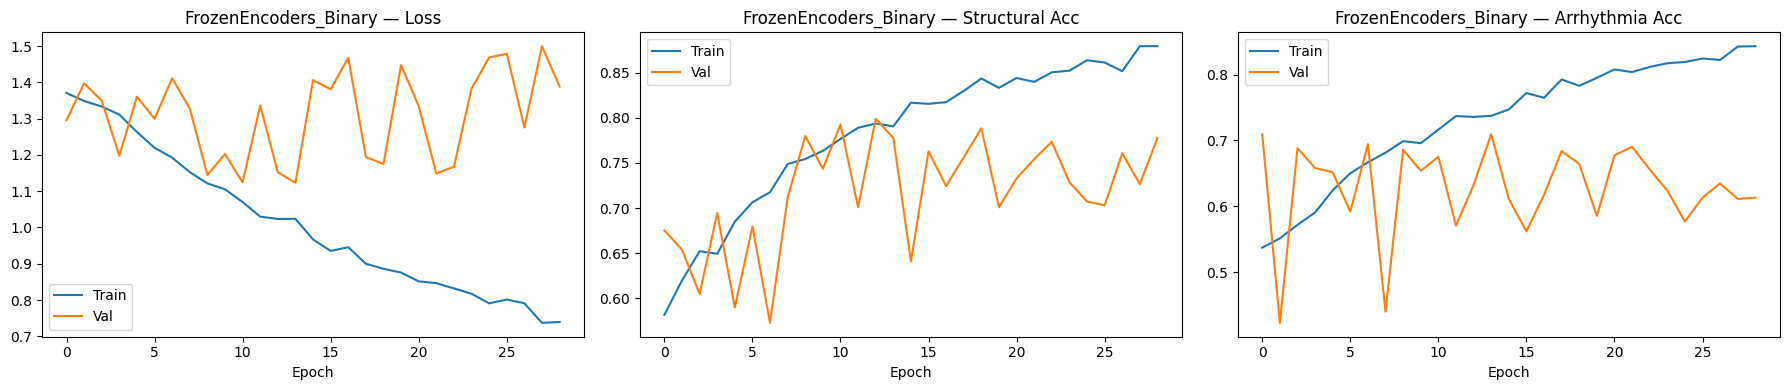

In [7]:
scaler    = torch.amp.GradScaler() if DEVICE.type == 'cuda' else None
ckpt_best = os.path.join(OUTPUT_DIR, 'binary_best.pt')

best_combined_f1 = 0.0
history = {'train_loss':[], 'val_loss':[],
           'train_s_acc':[], 'val_s_acc':[],
           'train_a_acc':[], 'val_a_acc':[]}

# ── Collect only trainable parameters ─────────────────────────────────────────
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameters: {sum(p.numel() for p in trainable_params)/1e6:.2f} M")

# ── Optimizer with separate decay groups ──────────────────────────────────────
no_decay_names = {'bias', 'LayerNorm.weight', 'LayerNorm.bias',
                  'BatchNorm1d.weight', 'BatchNorm1d.bias'}
decay_params    = [p for n, p in model.named_parameters()
                   if p.requires_grad and not any(nd in n for nd in no_decay_names)]
no_decay_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and any(nd in n for nd in no_decay_names)]

optimizer = torch.optim.AdamW([
    {'params': decay_params,    'weight_decay': 0.05},
    {'params': no_decay_params, 'weight_decay': 0.0},
], lr=LR)

# ── Warmup + Cosine schedule ─────────────────────────────────────────────────
warmup_epochs = 5
warmup_sched  = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
)
cosine_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - warmup_epochs, eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[warmup_epochs]
)

no_improve = 0

print(f"\n{'='*70}")
print(f"  Training: Frozen encoders — fusion + heads")
print(f"  Epochs={EPOCHS}  LR={LR}  Batch={BATCH_SIZE}  Patience={PATIENCE}")
print(f"  Trainable: {sum(p.numel() for p in trainable_params)/1e6:.2f}M / "
      f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M")
print(f"{'='*70}")

for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tl, tsa, taa = run_epoch_mt(model, train_loader, crit_struct, crit_arr, optimizer, scaler)
    vl, vsa, vaa = run_epoch_mt(model, val_loader,   crit_struct, crit_arr)
    scheduler.step()

    sf1, af1, combined_f1 = compute_combined_f1(model, val_loader)

    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_s_acc'].append(tsa); history['val_s_acc'].append(vsa)
    history['train_a_acc'].append(taa); history['val_a_acc'].append(vaa)

    flag = ''
    if combined_f1 > best_combined_f1:
        best_combined_f1 = combined_f1
        no_improve = 0
        torch.save(model.state_dict(), ckpt_best)
        flag = '  <- BEST'
    else:
        no_improve += 1

    cur_lr = optimizer.param_groups[0]['lr']
    print(f"  {ep:03d}/{EPOCHS} | "
          f"tr {tl:.3f} s={tsa:.3f} a={taa:.3f} | "
          f"val {vl:.3f} s={vsa:.3f} a={vaa:.3f} | "
          f"F1: s={sf1:.3f} a={af1:.3f} avg={combined_f1:.3f}{flag} | "
          f"lr={cur_lr:.1e} | {time.time()-t0:.1f}s")

    if ep % 5 == 0 or ep == 1:
        model.gate_summary()

    if no_improve >= PATIENCE:
        print(f"  Early stopping at epoch {ep}")
        break

print(f"\n{'='*70}")
print(f"  TRAINING COMPLETE — Best combined F1: {best_combined_f1:.4f}")
print(f"{'='*70}")
plot_history_mt(history, 'FrozenEncoders_Binary')

## 6 · Test Set Evaluation

**Binary metrics:** AUROC, AUPRC, Sensitivity, Specificity, F1, confusion matrices, ROC/PR curves.

TEST SET RESULTS — Binary Screening (Normal vs Abnormal)

--- STRUCTURAL DISEASE ---
  AUROC       : 0.6771
  AUPRC       : 0.9391
  F1          : 0.8712
  Sensitivity : 0.8318
  Specificity : 0.3889
              precision    recall  f1-score   support

      normal      0.227     0.389     0.287       108
    abnormal      0.915     0.832     0.871       850

    accuracy                          0.782       958
   macro avg      0.571     0.610     0.579       958
weighted avg      0.837     0.782     0.805       958

--- ARRHYTHMIA ---
  AUROC       : 0.5857
  AUPRC       : 0.7837
  F1          : 0.7746
  Sensitivity : 0.7718
  Specificity : 0.3669
              precision    recall  f1-score   support

      normal      0.360     0.367     0.363       248
    abnormal      0.777     0.772     0.775       710

    accuracy                          0.667       958
   macro avg      0.568     0.569     0.569       958
weighted avg      0.669     0.667     0.668       958



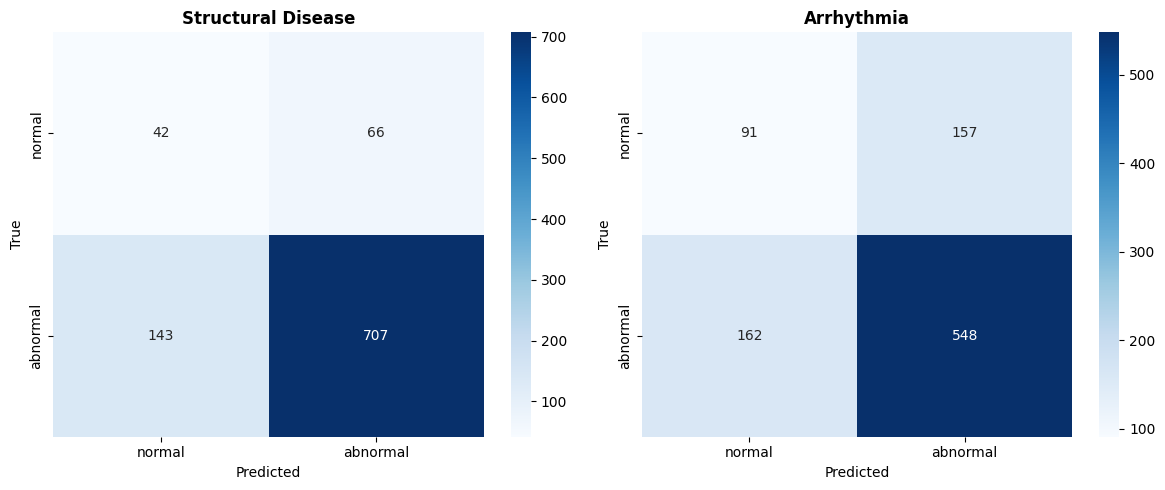

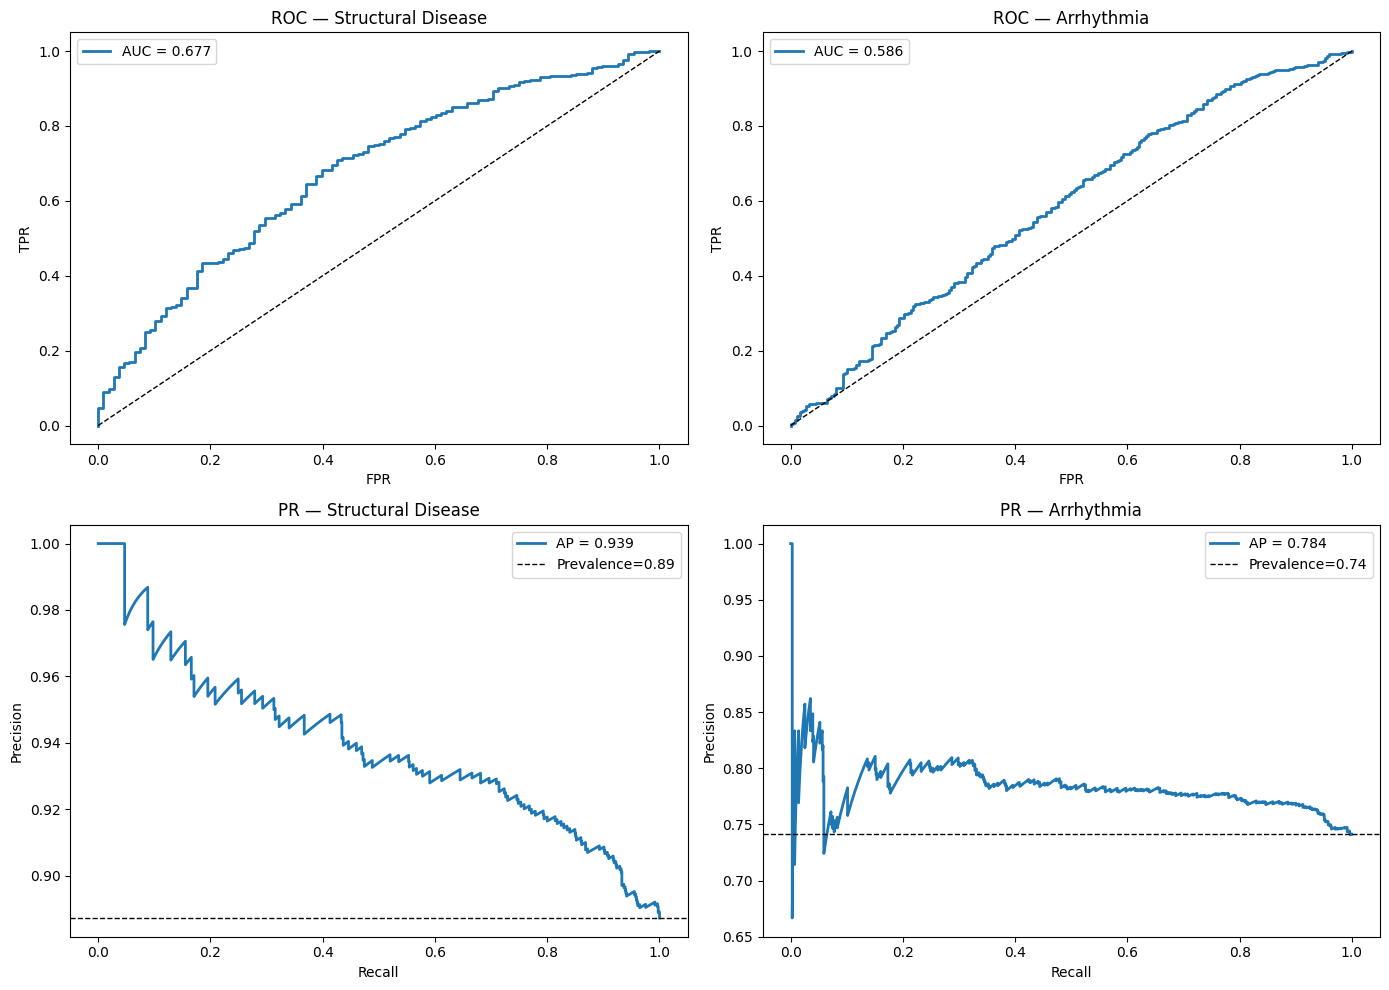


COMBINED SCORE
  AUROC  : 0.6314
  AUPRC  : 0.8614
  F1     : 0.8229


In [8]:
model.load_state_dict(torch.load(ckpt_best, map_location=DEVICE))
s_true, s_probs, a_true, a_probs = evaluate_mt(model, test_loader)

# Binary scores: P(abnormal) = column 1
s_score = s_probs[:, 1]
a_score = a_probs[:, 1]
s_preds = (s_score >= 0.5).astype(int)
a_preds = (a_score >= 0.5).astype(int)

# AUROC
s_auroc = roc_auc_score(s_true, s_score)
a_auroc = roc_auc_score(a_true, a_score)

# AUPRC
s_auprc = average_precision_score(s_true, s_score)
a_auprc = average_precision_score(a_true, a_score)

# F1, Sensitivity, Specificity
s_f1 = f1_score(s_true, s_preds, zero_division=0)
a_f1 = f1_score(a_true, a_preds, zero_division=0)

def sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sens, spec

s_sens, s_spec = sensitivity_specificity(s_true, s_preds)
a_sens, a_spec = sensitivity_specificity(a_true, a_preds)

print("=" * 70)
print("TEST SET RESULTS — Binary Screening (Normal vs Abnormal)")
print("=" * 70)

print(f"\n--- STRUCTURAL DISEASE ---")
print(f"  AUROC       : {s_auroc:.4f}")
print(f"  AUPRC       : {s_auprc:.4f}")
print(f"  F1          : {s_f1:.4f}")
print(f"  Sensitivity : {s_sens:.4f}")
print(f"  Specificity : {s_spec:.4f}")
print(classification_report(s_true, s_preds, target_names=STRUCT_CLASSES, digits=3))

print(f"--- ARRHYTHMIA ---")
print(f"  AUROC       : {a_auroc:.4f}")
print(f"  AUPRC       : {a_auprc:.4f}")
print(f"  F1          : {a_f1:.4f}")
print(f"  Sensitivity : {a_sens:.4f}")
print(f"  Specificity : {a_spec:.4f}")
print(classification_report(a_true, a_preds, target_names=ARR_CLASSES, digits=3))

# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, preds, names, title in [
    (axes[0], s_true, s_preds, STRUCT_CLASSES, 'Structural Disease'),
    (axes[1], a_true, a_preds, ARR_CLASSES,    'Arrhythmia'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_binary.png'), dpi=150)
plt.show()

# ── ROC + PR curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (true, score, title) in enumerate([
    (s_true, s_score, 'Structural Disease'),
    (a_true, a_score, 'Arrhythmia'),
]):
    # ROC
    fpr, tpr, _ = roc_curve(true, score)
    auc_val = roc_auc_score(true, score)
    axes[0, col].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.3f}')
    axes[0, col].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0, col].set_xlabel('FPR'); axes[0, col].set_ylabel('TPR')
    axes[0, col].set_title(f'ROC — {title}')
    axes[0, col].legend()

    # PR
    prec, rec, _ = precision_recall_curve(true, score)
    ap = average_precision_score(true, score)
    axes[1, col].plot(rec, prec, lw=2, label=f'AP = {ap:.3f}')
    prevalence = true.mean()
    axes[1, col].axhline(prevalence, color='k', ls='--', lw=1, label=f'Prevalence={prevalence:.2f}')
    axes[1, col].set_xlabel('Recall'); axes[1, col].set_ylabel('Precision')
    axes[1, col].set_title(f'PR — {title}')
    axes[1, col].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_pr_binary.png'), dpi=150)
plt.show()

print(f"\n{'='*70}")
print(f"COMBINED SCORE")
print(f"  AUROC  : {(s_auroc + a_auroc) / 2:.4f}")
print(f"  AUPRC  : {(s_auprc + a_auprc) / 2:.4f}")
print(f"  F1     : {(s_f1 + a_f1) / 2:.4f}")
print(f"{'='*70}")

## 7 · XAI — Electromechanical Attribution Maps

Cross-attention and gate visualisation. In the binary setting, gate asymmetry should be clearer:
- Structural head: echo gate > ECG gate (structural abnormalities are visible in echo)
- Arrhythmia head: ECG gate > echo gate (rhythm abnormalities are in ECG)

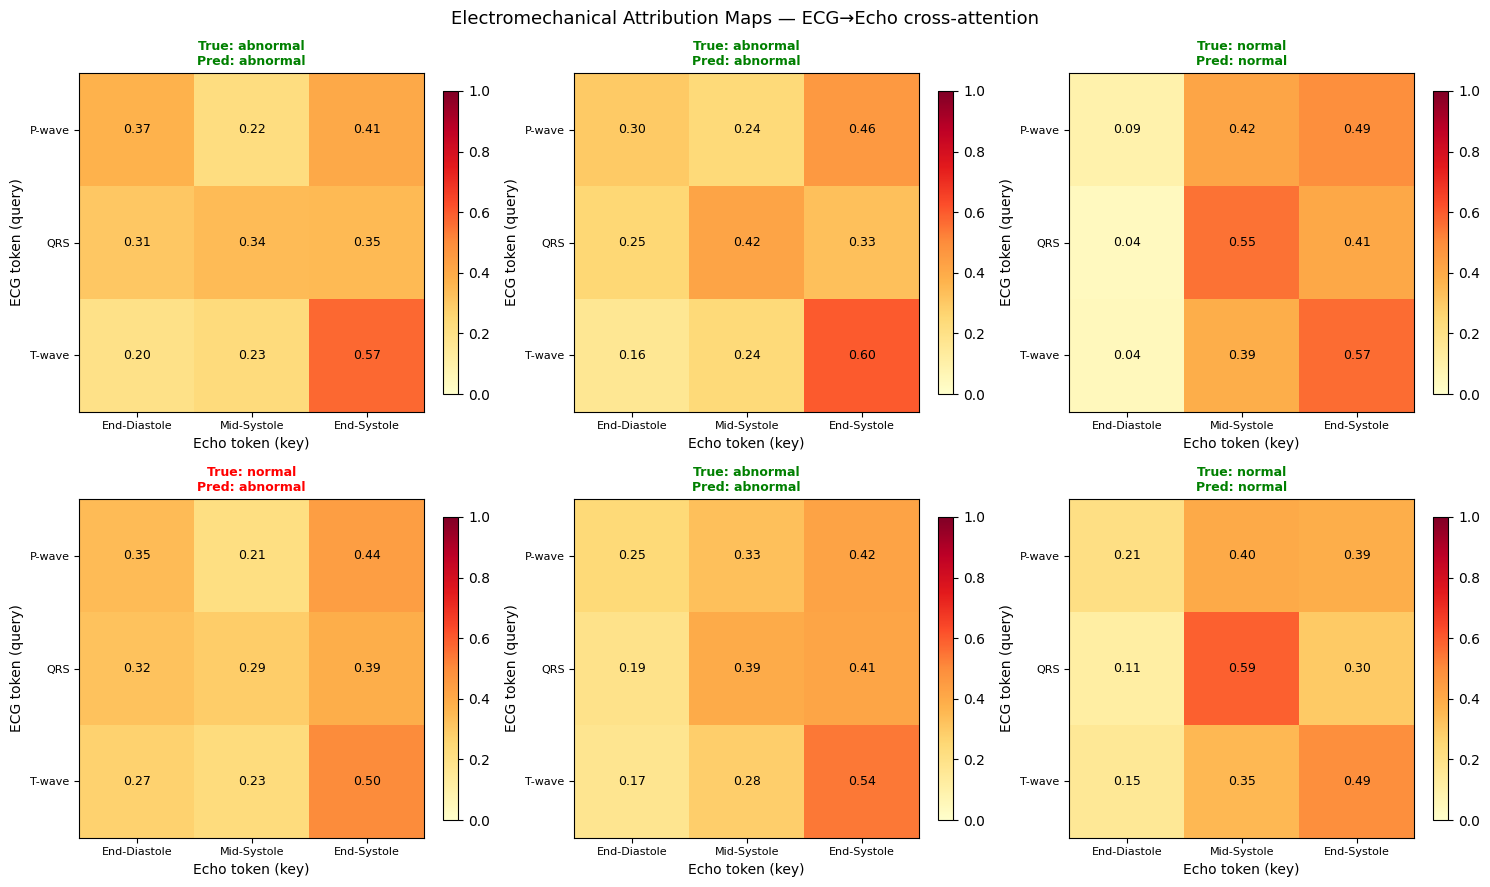

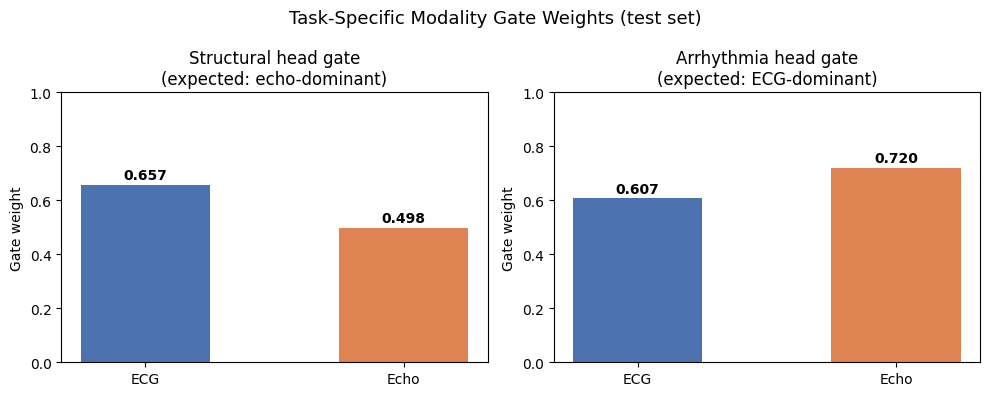

In [9]:
ECG_TOK_NAMES  = ['P-wave', 'QRS', 'T-wave']
ECHO_TOK_NAMES = ['End-Diastole', 'Mid-Systole', 'End-Systole']

def plot_eam(model, loader, num_samples=6):
    model.eval()
    collected = []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for ecg, echo, labels, _ in loader:
            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    logits, _ = model(ecg.to(DEVICE), echo.to(DEVICE))
            else:
                logits, _ = model(ecg.to(DEVICE), echo.to(DEVICE))
            preds = logits.argmax(1).cpu()
            w = model.fusion.attn_weights['ecg_to_echo'].float()
            for i in range(len(labels)):
                collected.append(dict(
                    attn    = w[i].numpy(),
                    true    = STRUCT_CLASSES[labels[i]],
                    pred    = STRUCT_CLASSES[preds[i]],
                    correct = (labels[i] == preds[i]).item()
                ))
            if len(collected) >= num_samples:
                break

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, s in zip(axes.flat, collected):
        im = ax.imshow(s['attn'], vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
        ax.set_xticks(range(3)); ax.set_xticklabels(ECHO_TOK_NAMES, fontsize=8)
        ax.set_yticks(range(3)); ax.set_yticklabels(ECG_TOK_NAMES,  fontsize=8)
        ax.set_xlabel('Echo token (key)');  ax.set_ylabel('ECG token (query)')
        color = 'green' if s['correct'] else 'red'
        ax.set_title(f"True: {s['true']}\nPred: {s['pred']}",
                     color=color, fontsize=9, fontweight='bold')
        for r in range(3):
            for c in range(3):
                ax.text(c, r, f"{s['attn'][r,c]:.2f}",
                        ha='center', va='center', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.04)

    plt.suptitle('Electromechanical Attribution Maps — ECG→Echo cross-attention', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'eam_samples.png'), dpi=150)
    plt.show()


plot_eam(model, test_loader, num_samples=6)

# ── Modality Gate Visualisation ──────────────────────────────────────────────

def plot_gates(model, loader, num_batches=5):
    model.eval()
    gs_list, ga_list = [], []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for i, (ecg, echo, _, _) in enumerate(loader):
            if i >= num_batches:
                break
            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    model(ecg.to(DEVICE), echo.to(DEVICE))
            else:
                model(ecg.to(DEVICE), echo.to(DEVICE))
            gs_list.append(model._g_struct.float().cpu())
            ga_list.append(model._g_arr.float().cpu())

    gs = torch.cat(gs_list).mean(0)
    ga = torch.cat(ga_list).mean(0)

    labels = ['ECG', 'Echo']
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, weights, title, expected in [
        (axes[0], gs, 'Structural head gate',  'echo-dominant'),
        (axes[1], ga, 'Arrhythmia head gate', 'ECG-dominant'),
    ]:
        bars = ax.bar(labels, weights.numpy(), color=['#4C72B0', '#DD8452'], width=0.5)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Gate weight')
        ax.set_title(f'{title}\n(expected: {expected})')
        for bar, v in zip(bars, weights):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                    f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    plt.suptitle('Task-Specific Modality Gate Weights (test set)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gate_weights.png'), dpi=150)
    plt.show()

plot_gates(model, test_loader)

## 8 · Save Final Checkpoint

In [10]:
final_path = os.path.join(OUTPUT_DIR, 'cardiac_fusion_binary_v6_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'struct_classes'  : STRUCT_CLASSES,
    'arr_classes'     : ARR_CLASSES,
    'config': dict(
        ecg_base_dim       = ECG_BASE_DIM,
        echo_base_dim      = ECHO_BASE_DIM,
        proj_dim           = PROJ_DIM,
        attn_heads         = ATTN_HEADS,
        attn_layers        = ATTN_LAYERS,
        ecg_seq_len        = ECG_SEQ_LEN,
        ecg_trans_layers   = ECG_TRANS_LAYERS,
        num_classes_struct = NUM_CLASSES_STRUCT,
        num_classes_arr    = NUM_CLASSES_ARR,
    ),
    'history': history,
    'pretrained_ecg_ckpt': PRETRAINED_ECG_CKPT,
}, final_path)

print(f"Saved: {final_path}")
print("\nAll output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1e6
    print(f"  {f:45s}  {mb:7.1f} MB")

Saved: C:\Users\anwme\Desktop\Datasets\model_output_binary_v6\cardiac_fusion_binary_v6_final.pt

All output files:
  binary_best.pt                                   127.5 MB
  cardiac_fusion_binary_v6_final.pt                127.5 MB
  cm_binary.png                                      0.0 MB
  eam_samples.png                                    0.2 MB
  gate_weights.png                                   0.0 MB
  history_FrozenEncoders_Binary.png                  0.2 MB
  roc_pr_binary.png                                  0.2 MB
